In [1]:
import pandas as pd
df= pd.read_csv(r'C:\Users\DELL\Desktop\House Price Prediction Dataset.csv')

In [2]:
print(df.shape)

(2000, 10)


In [3]:
print(df.isnull().sum())

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


In [4]:
print(df.duplicated().sum())

0


In [5]:
print(df.dtypes)

Id            int64
Area          int64
Bedrooms      int64
Bathrooms     int64
Floors        int64
YearBuilt     int64
Location     object
Condition    object
Garage       object
Price         int64
dtype: object


In [6]:
print(df.describe())

                Id         Area     Bedrooms   Bathrooms       Floors  \
count  2000.000000  2000.000000  2000.000000  2000.00000  2000.000000   
mean   1000.500000  2786.209500     3.003500     2.55250     1.993500   
std     577.494589  1295.146799     1.424606     1.10899     0.809188   
min       1.000000   501.000000     1.000000     1.00000     1.000000   
25%     500.750000  1653.000000     2.000000     2.00000     1.000000   
50%    1000.500000  2833.000000     3.000000     3.00000     2.000000   
75%    1500.250000  3887.500000     4.000000     4.00000     3.000000   
max    2000.000000  4999.000000     5.000000     4.00000     3.000000   

         YearBuilt          Price  
count  2000.000000    2000.000000  
mean   1961.446000  537676.855000  
std      35.926695  276428.845719  
min    1900.000000   50005.000000  
25%    1930.000000  300098.000000  
50%    1961.000000  539254.000000  
75%    1993.000000  780086.000000  
max    2023.000000  999656.000000  


Before modeling, I expected Area to be the strongest predictor of price, since larger houses typically cost more.Bedrooms and Bathrooms were also expected to correlate positively. Yearbuilt could go either way ; newer houses might be worth more or older houses in established areas may hold value. Location and condition were expected to matter qualtitatively, since " excellent " condition or "urban" location often commands  premium.

In [7]:
df

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
...,...,...,...,...,...,...,...,...,...,...
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119


In [8]:
df_encoded = pd.get_dummies(df,columns=['Location','Condition','Garage'],drop_first=True)

In [9]:
print(df_encoded.columns.tolist())

['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price', 'Location_Rural', 'Location_Suburban', 'Location_Urban', 'Condition_Fair', 'Condition_Good', 'Condition_Poor', 'Garage_Yes']


In [10]:
print(df_encoded.shape)

(2000, 14)


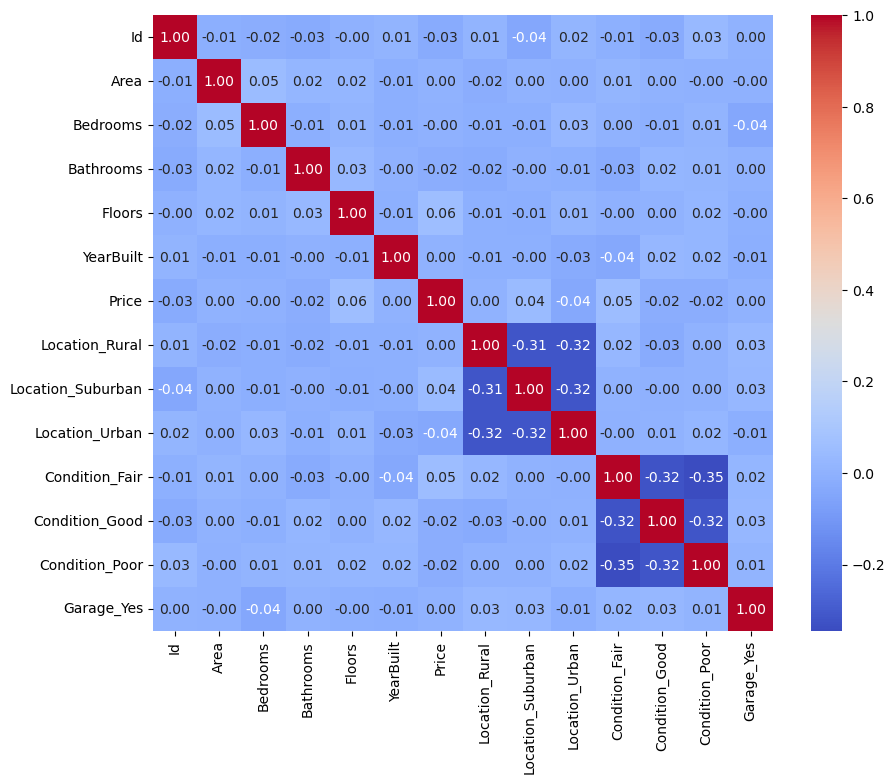

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt 
plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(), annot =True, cmap='coolwarm', fmt='.2f')
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
x= df_encoded.drop('Price', axis=1)
y=df_encoded['Price']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [13]:
print(x_train.shape)

(1600, 13)


In [14]:
print(x_test.shape)

(400, 13)


In [15]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
y_pred = model.predict(x_test)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2=r2_score(y_test,y_pred)
print("MAE:",mae)
print("RMSE:", rmse)
print("R2:",r2)
print("MSE:",mse)

MAE: 242867.44926338628
RMSE: 279785.21069002635
R2: -0.006181784611834162
MSE: 78279764120.86243


### CONCLUSION 
The Linear Regression model achieved an R2 of approximately -0.006, indicating it explains essentially none of the variance in house prices . This aligns with the correlation heatmap, which showed near-zero correlation between all features and Price. This suggests that the data set may not encode a genuine linear relationship beyween the given features and price;possibly synthetic/random price assignment.A more complex or non linear model(e.g Random forest) is unlikely to help much either, since the underlying features carry little predictive signal.

In [17]:
from sklearn.ensemble import RandomForestRegressor 
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(x_train,y_train)

rf_pred = rf_model.predict(x_test)

rf_mae = mean_absolute_error(y_test,rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)

Random Forest MAE: 249685.404225
Random Forest RMSE: 288572.66278199374
Random Forest R2: -0.07037835002606019


### IN ADDITION 
To test a non-linear model could capture patterns Linear Regression missed, a Random forest was also trained .It performed even worse (R2 = -0.070 vs -0.006), which rules out model choice as the limitation and confirms that Price in the dataset carries no meaningful relationship with the given features ; most likely due to synthetic/random price generation.

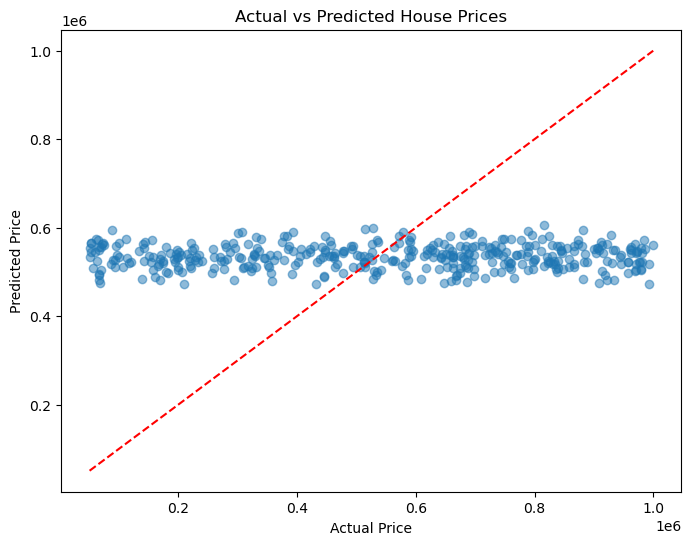

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color ='red', linestyle='--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

The scatter plot confirms the weak R2 numerically observed earlier:predicted prices cluster tightly around 500,000 -550,000 nairs regardless of the actual price, showing the model essentially predicts the average price rather than learning any real pattern from the features.

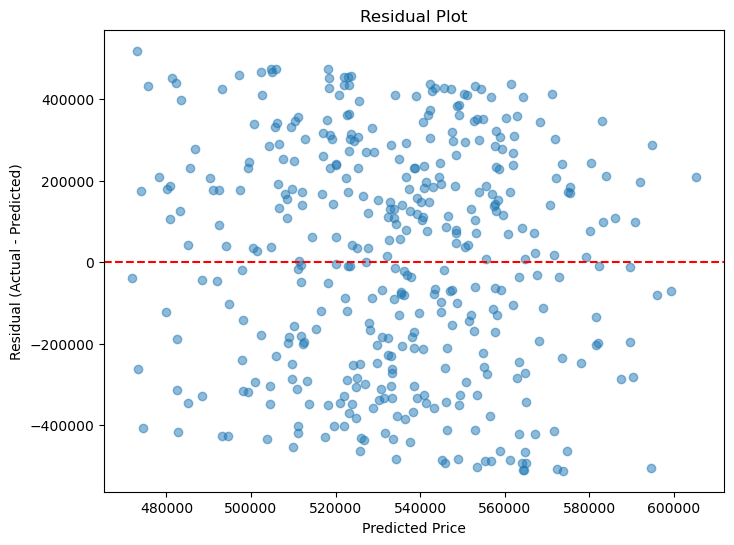

In [23]:
residuals = y_test -y_pred
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha= 0.5)
plt.axhline(y=0, color='red',linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

The residual plot shows no systematic pattern ; residuals are randomly and symetrically distributed around zero, indicating no bias in this error.However, the narrow  range of predicted values (480,000-600,000) naira compared to the full range of actual prices confirms the model is not meaninfully differentiating between houses. It produces nearly the same prediction regardless of input features.

In [25]:
coefficients =pd.DataFrame({
'Feature':x_train.columns,
'coefficient':model.coef_
})
coefficients = coefficients.sort_values(by='coefficient',ascending=False)
print (coefficients)

              Feature   coefficient
9      Condition_Fair  24049.504733
4              Floors  23582.408499
7   Location_Suburban  11110.139855
11     Condition_Poor   4389.783506
12         Garage_Yes   2218.649484
6      Location_Rural   1826.466887
5           YearBuilt    116.775334
2            Bedrooms     53.249124
1                Area     -0.484192
0                  Id    -12.007473
3           Bathrooms  -9835.704344
8      Location_Urban -12601.589640
10     Condition_Good -13048.175894


Coefficent analysis further confirms the earlier findings:Area, the feature expected to be the strongest price driver, has a coefficient near zero(0.48), meaning house size has essentially no predicted effect on price. The largest coefficients(Condition_Fair, Floors) are still small relative to typical price magnitudes and follow no intuitive real world logic (e.g.,'Fair' conditiion out weighing 'excellent').This reinforces that the dataset doesnt not encode a realistics, learnable price relationship.